# **Dataset Evolution Audit: Raw vs. Feature v4**
### **Objective:** Structural integrity and schema evolution tracking for production readiness.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("Initializing Audit...")
df_raw = pd.read_csv('../Dataset/raw_data.csv')
df_feat = pd.read_csv('../Dataset/feature_data_v4.csv')

print(f"Raw: {df_raw.shape[0]} rows | Feature v4: {df_feat.shape[0]} rows")

Initializing Audit...
Raw: 69975 rows | Feature v4: 69926 rows


## **STEP 1: Schema Evolution Analysis**
Detecting dropped identifiers and synthetic feature expansion.

In [3]:
raw_cols = set(df_raw.columns)
feat_cols = set(df_feat.columns)

dropped = raw_cols - feat_cols
added = feat_cols - raw_cols

print(f"✅ Dropped Columns (Noise): {dropped}")
print(f"✅ Added Columns (Features): {len(added)}")

✅ Dropped Columns (Noise): {'order_id'}
✅ Added Columns (Features): 29


## **STEP 2: Target Distribution Stability**
Verifying that feature engineering did not drift the `delivery_time_hours` distribution.

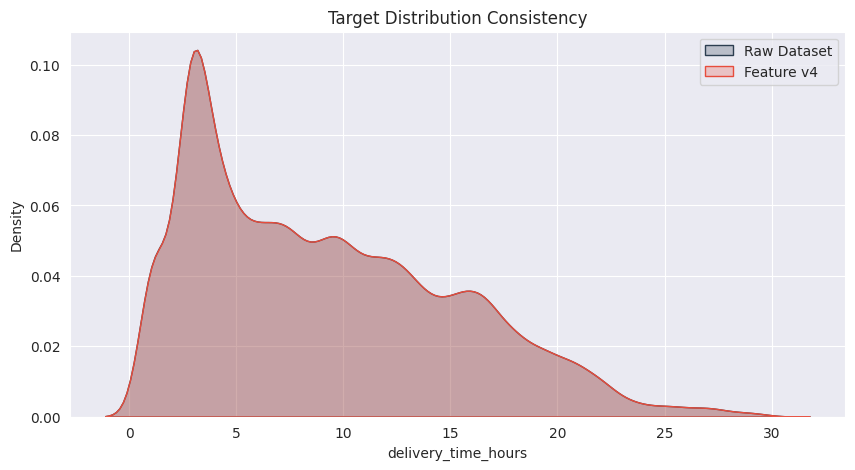

In [4]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_raw['delivery_time_hours'], label='Raw Dataset', fill=True, color='#2c3e50')
sns.kdeplot(df_feat['delivery_time_hours'], label='Feature v4', fill=True, color='#e74c3c')
plt.title("Target Distribution Consistency")
plt.legend()
plt.show()